In [1]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.optimizers import SGD
from tensorflow.random import set_seed

set_seed(455)
np.random.seed(455)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kalilurrahman/mastercard-stock-data-latest-and-updated")

print("Path to dataset files:", path)

100%|██████████| 195k/195k [00:00<00:00, 32.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kalilurrahman/mastercard-stock-data-latest-and-updated/versions/917


In [55]:
dataset = pd.read_csv(
    f"{path}/Mastercard_stock_history.csv", index_col="Date", parse_dates=["Date"]
).drop(["Dividends", "Stock Splits"], axis=1)
# Explicitly convert index to DatetimeIndex with utc=True
dataset.index = pd.to_datetime(dataset.index, utc=True)
print(dataset.tail())

                                 Open        High         Low       Close  \
Date                                                                        
2025-03-12 04:00:00+00:00  530.510010  532.710022  519.260010  524.640015   
2025-03-13 04:00:00+00:00  524.500000  528.530029  517.710022  519.830017   
2025-03-14 04:00:00+00:00  522.599976  528.409973  520.950012  527.640015   
2025-03-17 04:00:00+00:00  523.250000  533.479980  521.479980  531.989990   
2025-03-18 04:00:00+00:00  532.340027  532.590027  525.510010  528.354980   

                            Volume  
Date                                
2025-03-12 04:00:00+00:00  2810800  
2025-03-13 04:00:00+00:00  2375800  
2025-03-14 04:00:00+00:00  2369500  
2025-03-17 04:00:00+00:00  2544800  
2025-03-18 04:00:00+00:00   901928  


In [26]:
print(dataset.describe())

              Open         High          Low        Close        Volume
count  4733.000000  4733.000000  4733.000000  4733.000000  4.733000e+03
mean    157.218445   158.751430   155.650434   157.248719  1.062101e+07
std     151.827873   153.182400   150.433224   151.846666  1.632991e+07
min       3.677800     4.024589     3.668674     4.006337  6.411000e+05
25%      24.703870    25.007020    24.386382    24.721483  3.020000e+06
50%      87.602214    88.402167    86.976627    87.724739  4.742400e+06
75%     298.458871   302.054722   294.400031   298.368073  1.062100e+07
max     577.330017   582.229980   570.000000   576.309998  3.953430e+08


In [27]:
dataset.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0


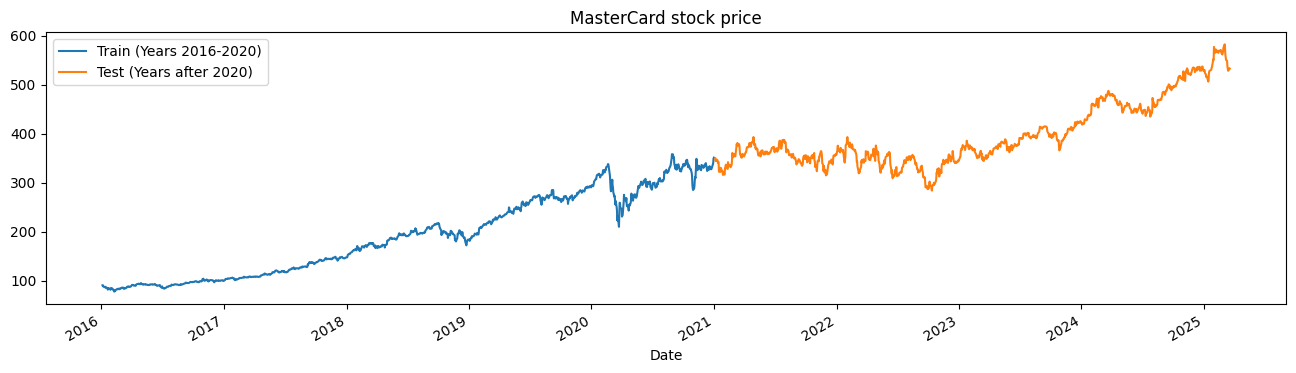

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

tstart = 2016
tend = 2020

def train_test_plot(dataset, tstart, tend):
    # Filter the dataset based on the year using correct boolean indexing
    train_data = dataset[(dataset.index.year >= tstart) & (dataset.index.year <= tend)]
    test_data = dataset[dataset.index.year > tend]

    train_data["High"].plot(figsize=(16, 4), legend=True)
    test_data["High"].plot(figsize=(16, 4), legend=True)
    plt.legend([f"Train (Years {tstart}-{tend})", f"Test (Years after {tend})"])
    plt.title("MasterCard stock price")
    plt.show()

train_test_plot(dataset,tstart,tend)

In [59]:
import pandas as pd

def train_test_split(dataset, tstart, tend):
    # Filter the dataset based on the year using correct boolean indexing
    train_data = dataset[(dataset.index.year >= tstart) & (dataset.index.year <= tend)]
    test_data = dataset[dataset.index.year > tend]

    train = train_data["High"].values
    test = test_data["High"].values
    return train, test
training_set, test_set = train_test_split(dataset, tstart, tend)

In [60]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set = training_set.reshape(-1, 1)
training_set_scaled = sc.fit_transform(training_set)

In [61]:
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


n_steps = 60
features = 1
# split into samples
X_train, y_train = split_sequence(training_set_scaled, n_steps)

In [62]:
# Reshaping X_train for model
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],features)


In [63]:
# The LSTM architecture
model_lstm = Sequential()
model_lstm.add(LSTM(units=125, activation="tanh", input_shape=(n_steps, features)))
model_lstm.add(Dense(units=1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [64]:
# Compiling the model
model_lstm.compile(optimizer="RMSprop", loss="mse")

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 125)            │        63,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,626 (248.54 KB)

 Trainable params: 63,626 (248.54 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model_lstm.fit(X_train, y_train, epochs=50, batch_size=32, verbose=False)

In [67]:
dataset_total = dataset.loc[:,"High"]
inputs = dataset_total[len(dataset_total) - len(test_set) - n_steps :].values
inputs = inputs.reshape(-1, 1)
#scaling
inputs = sc.transform(inputs)

# Split into samples
X_test, y_test = split_sequence(inputs, n_steps)
# reshape
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], features)
#prediction
predicted_stock_price = model_lstm.predict(X_test)
#inverse transform the values
predicted_stock_price = sc.inverse_transform(predicted_stock_price)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step


In [68]:
def plot_predictions(test, predicted):
    plt.plot(test, color="gray", label="Real")
    plt.plot(predicted, color="red", label="Predicted")
    plt.title("MasterCard Stock Price Prediction")
    plt.xlabel("Time")
    plt.ylabel("MasterCard Stock Price")
    plt.legend()
    plt.show()


def return_rmse(test, predicted):
    rmse = np.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {:.2f}.".format(rmse))


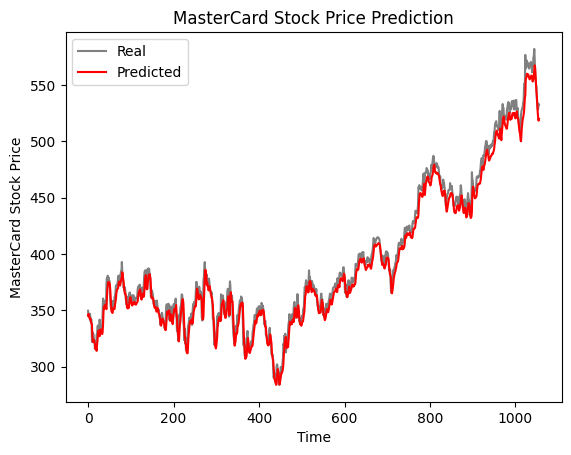

In [69]:
plot_predictions(test_set,predicted_stock_price)
